In [19]:
from qiskit import QuantumCircuit


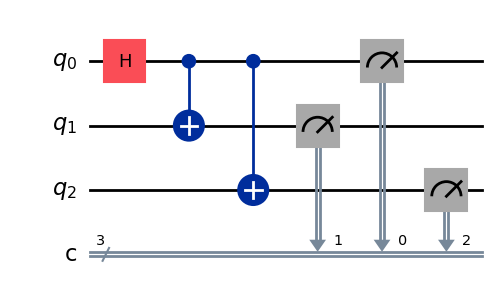

In [20]:
qc = QuantumCircuit(3, 3)

qc.h([0])

qc.cx(0,1)
qc.cx(0,2)

qc.measure([0,1,2], [0,1,2])
qc.draw(output='mpl')



In [13]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
result = sim.run(qc, shots=500).result()
counts = result.get_counts()

print(counts)

{'000': 256, '111': 244}


In [31]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

def show_step(name, build_circuit_fn, shots=1000):
    qc = build_circuit_fn()
    print(f"\n=== {name} ===")
    print(qc.draw())

    # 1) Etat quantique (sans mesure)
    sv = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))
    print("Probabilités théoriques:", sv.probabilities_dict())

    # 2) Mesure simulée
    sim = AerSimulator()
    result = sim.run(qc, shots=shots).result()
    print("Counts mesurés:", result.get_counts())

# A) H seul
show_step(
    "A: H(0)",
    lambda: (lambda q: (q.h(0), q.measure([0,1,2],[0,1,2]), q)[-1])(QuantumCircuit(3,3))
)

# B) H + CX(0,1)
show_step(
    "B: H(0), CX(0,1)",
    lambda: (lambda q: (q.h(0), q.cx(0,1), q.measure([0,1,2],[0,1,2]), q)[-1])(QuantumCircuit(3,3))
)

# C) H + CX(0,1) + CX(0,2)  -> GHZ
show_step(
    "C: H(0), CX(0,1), CX(0,2)",
    lambda: (lambda q: (q.h(0), q.cx(0,1), q.cx(0,2), q.measure([0,1,2],[0,1,2]), q)[-1])(QuantumCircuit(3,3))
)

# D) + H(0)
show_step(
    "D: C + H(0)",
    lambda: (lambda q: (q.h(0), q.cx(0,1), q.cx(0,2), q.h(0), q.measure([0,1,2],[0,1,2]), q)[-1])(QuantumCircuit(3,3))
)

# E) Ton circuit complet
show_step(
    "E: circuit complet",
    lambda: (lambda q: (q.h(0), q.cx(0,1), q.cx(0,2), q.h(0), q.cx(0,1), q.cx(0,2), q.measure([0,1,2],[0,1,2]), q)[-1])(QuantumCircuit(3,3))
)


=== A: H(0) ===
     ┌───┐   ┌─┐
q_0: ┤ H ├───┤M├
     └┬─┬┘   └╥┘
q_1: ─┤M├─────╫─
      └╥┘ ┌─┐ ║ 
q_2: ──╫──┤M├─╫─
       ║  └╥┘ ║ 
c: 3/══╩═══╩══╩═
       1   2  0 
Probabilités théoriques: {np.str_('000'): np.float64(0.4999999999999999), np.str_('001'): np.float64(0.4999999999999999)}
Counts mesurés: {'000': 484, '001': 516}

=== B: H(0), CX(0,1) ===
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
      ┌─┐ └───┘ ║ └╥┘
q_2: ─┤M├───────╫──╫─
      └╥┘       ║  ║ 
c: 3/══╩════════╩══╩═
       2        0  1 
Probabilités théoriques: {np.str_('000'): np.float64(0.4999999999999999), np.str_('011'): np.float64(0.4999999999999999)}
Counts mesurés: {'000': 457, '011': 543}

=== C: H(0), CX(0,1), CX(0,2) ===
     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
     